# Exploratory Data Analysis for EDA signal

Type: Skin conductance sensor\
Unit: microsiemens (μS)

EDA measures sweat gland activity.

**Why EDA is extremely important for stress detection**

Stress activates sweat glands, even if you don't see sweat.
| Condition | EDA  |
| --------- | ---- |
| Relaxed   | low  |
| Stress    | high |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../../Dataset/S2_chest_data.csv")
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return "stressed"
    elif label in nStr:
        return "not stressed"
    else:
        return "unknown"

df["target"] = df["Label"].apply(apply_target)

df.head(2)

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label,target
214583,0.8914,-0.1102,-0.2576,0.030945,-0.003708,5.710983,29.083618,1.191711,1,not stressed
214584,0.8926,-0.1086,-0.2544,0.033646,-0.014145,5.719376,29.122437,1.139832,1,not stressed


### EDA start from here

In [5]:
df["EDA"].describe()

count    2.022299e+06
mean     1.477928e+00
std      9.621079e-01
min      2.632141e-01
25%      7.904053e-01
50%      1.216888e+00
75%      1.777267e+00
max      5.756760e+00
Name: EDA, dtype: float64

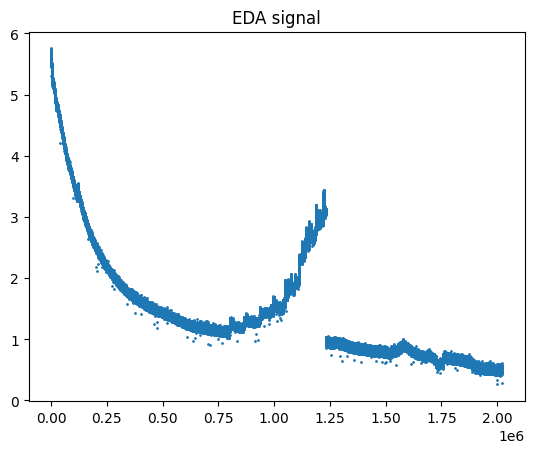

In [ ]:
plt.scatter(range(len(df)), df["EDA"], s=1)
plt.title("EDA signal")
plt.show()

**Why EDA is extremely important for stress detection**

Stress activates sweat glands, even if you don't see sweat.
| Condition | EDA  |
| --------- | ---- |
| Relaxed   | low  |
| Stress    | high |

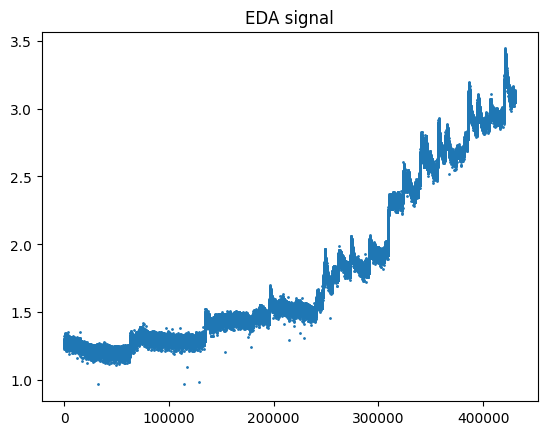

In [ ]:
str_EDA = df[df["target"] == "stressed"]
plt.scatter(range(len(str_EDA)), str_EDA["EDA"], s=1)
plt.title("EDA signal")
plt.show()

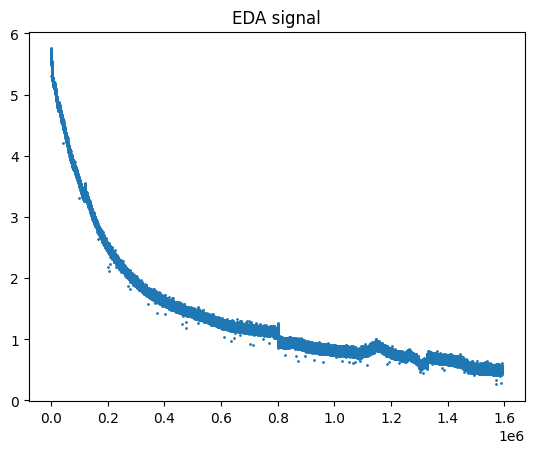

In [9]:
nStr_EDA = df[df["target"] == "not stressed"]
plt.scatter(range(len(nStr_EDA)), nStr_EDA["EDA"], s=1)
plt.title("EDA signal")
plt.show()

here outlier is because of the higher value of EDA for `not stress` EDA signal, but lower the `EDA` lower the chances of `stress`

### Checking outlier for stress class

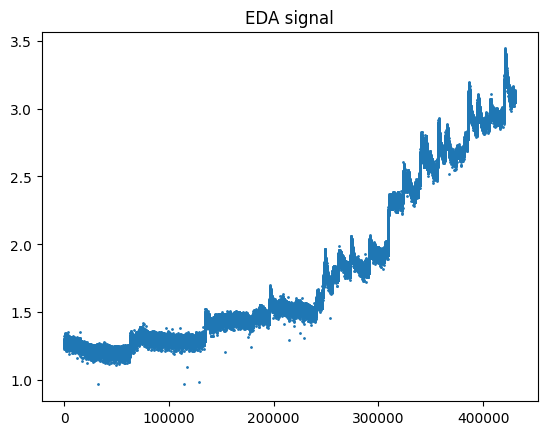

In [33]:
str_EDA = df[df["target"] == "stressed"]
plt.scatter(range(len(str_EDA)), str_EDA["EDA"], s=1)
plt.title("EDA signal")
plt.show()

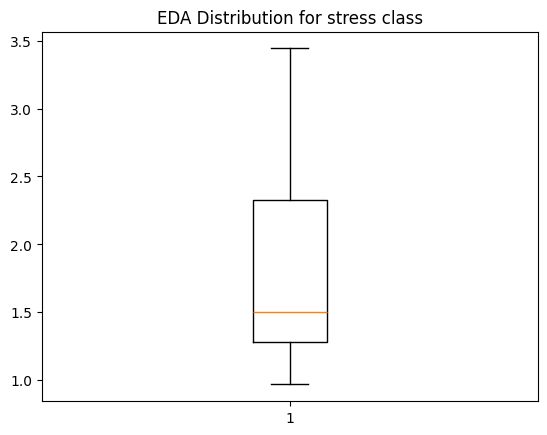

In [34]:
plt.boxplot(str_EDA["EDA"])
plt.title("EDA Distribution for stress class")
plt.show()

No outlier for stress class

### Checking outlier for `not stress` class

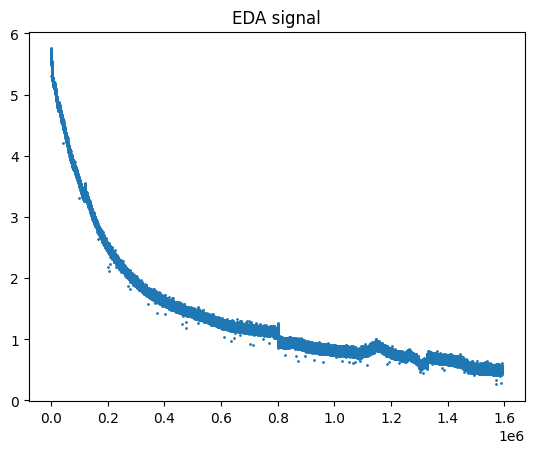

In [39]:
nStr_EDA = df[df["target"] == "not stressed"]
plt.scatter(range(len(nStr_EDA)), nStr_EDA["EDA"], s=1)
plt.title("EDA signal")
plt.show()

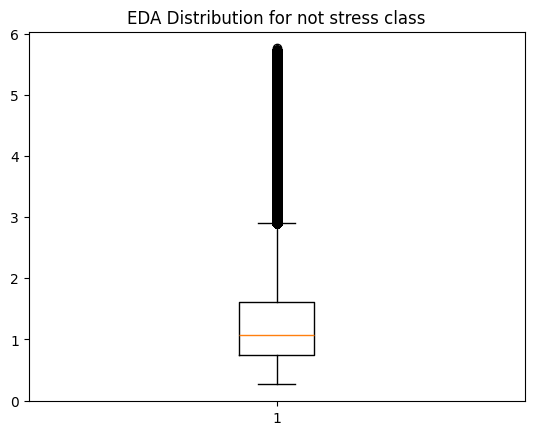

In [40]:
plt.boxplot(nStr_EDA["EDA"])
plt.title("EDA Distribution for not stress class")
plt.show()

outlier exist: remove them

C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_14036\3002214657.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["EDA"] >= lower) & (nStr_EDA["EDA"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_14036\3002214657.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["EDA"] >= lower) & (nStr_EDA["EDA"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_14036\3002214657.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["EDA"] >= lower) & (nStr_EDA["EDA"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_14036\3002214657.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["EDA"] >= lower) & (nStr_EDA["EDA"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_14036\3002214657.py:10: UserWarning: Boolean Series key will be reindexed to match Dat

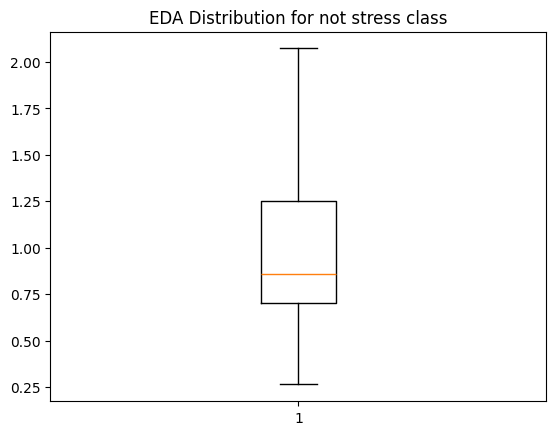

In [41]:
while True:
    Q1 = nStr_EDA["EDA"].quantile(0.25)
    Q3 = nStr_EDA["EDA"].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    new_df = nStr_EDA[(df["EDA"] >= lower) & (nStr_EDA["EDA"] <= upper)]

    # stop when no more rows are removed
    if len(new_df) == len(nStr_EDA):
        break

    nStr_EDA = new_df

plt.boxplot(nStr_EDA["EDA"])
plt.title("EDA Distribution for not stress class")
plt.show()

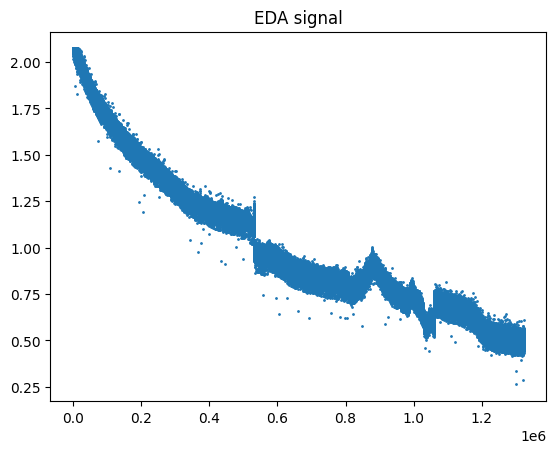

In [42]:
plt.scatter(range(len(nStr_EDA)), nStr_EDA["EDA"], s=1)
plt.title("EDA signal")
plt.show()

In [44]:
str_EDA["EDA"].describe()

count    430500.000000
mean          1.796925
std           0.613642
min           0.968170
25%           1.279068
50%           1.499557
75%           2.329731
max           3.442764
Name: EDA, dtype: float64

In [45]:
nStr_EDA["EDA"].describe()

count    1.323642e+06
mean     9.998497e-01
std      3.969834e-01
min      2.632141e-01
25%      6.996155e-01
50%      8.602142e-01
75%      1.248932e+00
max      2.072906e+00
Name: EDA, dtype: float64